---
title: "Dialect-Aware Arabic Translator"
format:
  html:
    code-fold: true
    code-tools: true
execute:
  enabled: true
---

In [8]:
# Needed Packages
# pip install transformers sentencepiece torch os subprocess pathlib

In [17]:
import os
import pandas as pd
import re
import subprocess
from pathlib import Path

def find_repo_root(repo_name="CS329"):
    try:
        root = subprocess.check_output(
            ["git", "rev-parse", "--show-toplevel"],
            stderr=subprocess.DEVNULL,
            text=True
        ).strip()
        root = Path(root)
        if root.name == repo_name:
            return root
    except Exception:
        pass

    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if p.name == repo_name and (p / ".git").exists():
            return p
        candidate = p / repo_name
        if candidate.exists() and (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError(f"Could not find repo '{repo_name}'")

repo_root = find_repo_root("CS329")
os.chdir(repo_root)
print("Using repo:", repo_root)

Using repo: C:\Users\Abasu\Documents\GitHub\CS329


Overall Test Accuracy: 0.9780

Region-Level Report:
               precision    recall  f1-score   support

         EGY       0.97      1.00      0.98        97
         GLF       0.96      0.99      0.97        94
         IRQ       1.00      0.95      0.97        78
         LEV       0.98      0.97      0.97        98
         MGH       0.99      0.98      0.98        88

    accuracy                           0.98       455
   macro avg       0.98      0.98      0.98       455
weighted avg       0.98      0.98      0.98       455



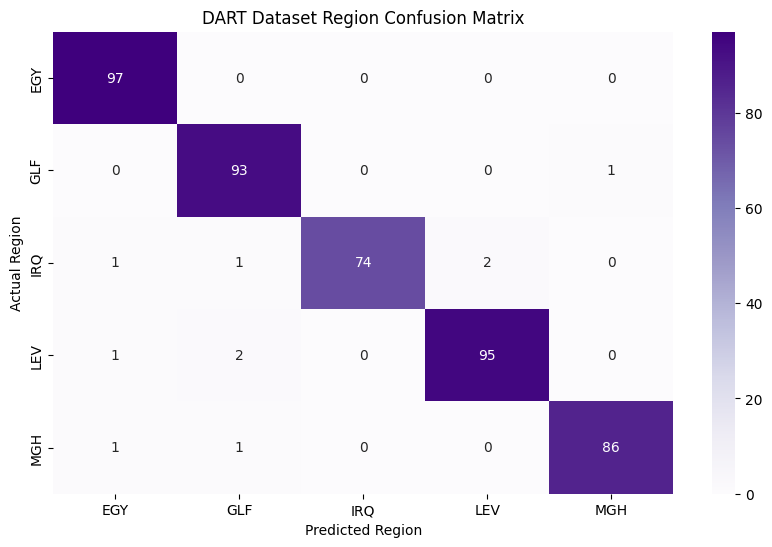

In [10]:
from Dialect_Detector import detect_dialect

In [11]:
# Load the OPUS-MT Arabic→English Model

from transformers import MarianMTModel, MarianTokenizer
import torch

MODEL_NAME = "Helsinki-NLP/opus-mt-ar-en"

tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
model = MarianMTModel.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)




c:\Users\Abasu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Abasu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Loading weights: 100%|██████████| 258/258 [00:00<00:00, 18366.72it/s]


MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(62834, 512, padding_idx=62833)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(62834, 512, padding_idx=62833)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLU()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,), eps=1e-05

In [12]:
# Dialect Normalization Layer (Key Innovation)
# Simple normalization dictionaries per dialect

# NEW: lets the function accept either the classifier label or our existing category name
DIALECT_LABEL_ALIASES = {
    "EGY": "egyptian",
    "LEV": "levantine",
    "LAV": "levantine",
    "GLF": "gulf",
    "IRQ": "iraqi",
    "MGH": "maghrebi",
    "NOR": "maghrebi",
    "MSA": "MSA"
}
    
DIALECT_NORMALIZATION = {
    "egyptian": {
        "رايح": "ذاهب",
        "جاي": "قادم",
        "عايز": "أريد",
        "عاوزه": "أريده",
        "مش": "ليس",
        "مش ب": "لا",
        "مش تعبان": "لست متعبا",
        "مش فاهم": "لا أفهم",
        "فين": "أين",
        "ليه": "لماذا",
        "كدة": "هكذا"
    },
    "levantine": {
        "راح": "ذهب",
        "بدّي": "أريد",
        "بدي": "أريد",
        "مو": "ليس",
        "مش": "ليس",
        "إجا": "جاء",
        "وين": "أين",
        "ليش": "لماذا",
        "شو": "ماذا",
        "هلق": "الآن",
        "كتير": "كثيرا"
    },
    "gulf": {
        "وين": "أين",
        "أبغى": "أريد",
        "أبي": "أريد",
        "مو": "ليس",
        "ليش": "لماذا","الحين": "الآن",
        "شلون": "كيف",
        "وايد": "كثيرا",
        "مب": "ليس"
    },
    "iraqi": {
        "ماكو": "لا يوجد",
        "مو": "ليس",
        "أروح": "أذهب",
        "وين": "أين",
        "ليش": "لماذا",
        "هسه": "الآن",
        "شنو": "ماذا",
        "كلش": "جدا"
    },
    "maghrebi": {
        "ما": "لا",
        "نبغي": "نريد",
        "بغيت": "أردت",
        "فين": "أين",
        "علاش": "لماذا",
        "دابا": "الآن",
        "بزاف": "كثيرا",
        "هاد": "هذا"
    },
    "MSA": {}
}

def normalize_dialect(text: str, dialect: str):
    """
    Replace dialectal words with MSA equivalents.
    Returns normalized text + list of applied rules.
    """
    applied_rules = []
    # NEW: map detector output labels to the dictionary category names used here
    dialect = DIALECT_LABEL_ALIASES.get(dialect, dialect)

    rules = DIALECT_NORMALIZATION.get(dialect, {})

    # NEW: start with the original full text so multi-word phrase rules can be applied first
    normalized_text = text

    # NEW: apply phrase-level replacements first
    for source, target in rules.items():
        if " " in source and source in normalized_text:
            normalized_text = normalized_text.replace(source, target)
            applied_rules.append(f"{source} → {target}")

    tokens = normalized_text.split()


    normalized_tokens = []
    for token in tokens:
        # NEW: strip punctuation around the token before matching
        clean_token = re.sub(r"[^\u0600-\u06FF]", "", token)

        if clean_token in rules:
            normalized_tokens.append(rules[clean_token])
            applied_rules.append(f"{clean_token} → {rules[clean_token]}")
        else:
            normalized_tokens.append(token)

    normalized_text = " ".join(normalized_tokens)
    return normalized_text, applied_rules

In [13]:
# Translation Function (OPUS-MT Inference)

def translate_ar_to_en(text: str, max_length: int = 128):
    """
    Translate Arabic text to English using OPUS-MT.
    """
    inputs = tokenizer(text, return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        translated = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=5,
            early_stopping=True
        )

    return tokenizer.decode(translated[0], skip_special_tokens=True)


In [14]:
# Explanation Layer (Ambiguity Awareness)
# This is post-processing, not modeling

AMBIGUOUS_WORDS = {
    "راح": ["went", "will go"],
    "كان": ["was", "used to be"],
    "طلع": ["went out", "turned out", "appeared"]
}

def get_ambiguity_notes(text: str):
    notes = []
    for word, meanings in AMBIGUOUS_WORDS.items():
        if word in text:
            notes.append({
                "word": word,
                "possible_meanings": meanings
            })
    return notes


In [15]:
# Main Pipeline (This Is What You Demo)
# Assumes You already have detect_dialect(text) implemented.


def dialect_aware_translate(text: str, detect_dialect):
    """
    Full pipeline:
    dialect detection → normalization → translation → explanations
    """
    dialect = detect_dialect(text)

    normalized_text, applied_rules = normalize_dialect(text, dialect)

    translation = translate_ar_to_en(normalized_text)

    ambiguity_notes = get_ambiguity_notes(text)

    return {
        "input_text": text,
        "detected_dialect": dialect,
        "normalized_text": normalized_text,
        "applied_normalization_rules": applied_rules,
        "translation": translation,
        "ambiguities": ambiguity_notes
    }


In [19]:
# NEW: Multiple example runs for live demo across dialects

examples = [
    "أنا رايح البيت ومش تعبان",          # EGY
    "شو بدّي أعمل هلق؟",                # LEV
    "شلونك الحين؟ هذا وايد زين",         # GLF
    "شنو تريد هسه؟",                    # IRQ
    "دابا بغيت نمشي، هاد بزاف"           # MGH
    "CS 329 RULES!"                 # NON_ARABIC
]

rows = []

for example in examples:
    result = dialect_aware_translate(example, detect_dialect)
    rows.append({
        "input_text": result["input_text"],
        "detected_dialect": result["detected_dialect"],
        "normalized_text": result["normalized_text"],
        "applied_rules": ", ".join(result["applied_normalization_rules"]),
        "translation": result["translation"]
    })

display(pd.DataFrame(rows))

,input_text,detected_dialect,normalized_text,applied_rules,translation
0,أنا رايح البيت ومش تعبان,EGY,أنا ذاهب البيت ولست متعبا,"مش تعبان → لست متعبا, رايح → ذاهب",I'm going home. I'm not tired.
1,شو بدّي أعمل هلق؟,LEV,ماذا أريد أعمل هلق؟,"شو → ماذا, بدّي → أريد",What do I want to do?
2,شلونك الحين؟ هذا وايد زين,GLF,شلونك الحين؟ هذا كثيرا زين,وايد → كثيرا,"That's a lot, Zane."
3,شنو تريد هسه؟,GLF,شنو تريد هسه؟,,"What do you want, huh?"
4,دابا بغيت نمشي، هاد بزافCS 329 RULES!,MGH,الآن أردت نمشي، هذا كثيرا 329 RULES!,"دابا → الآن, بغيت → أردت, هاد → هذا, بزاف → كثيرا","Now I wanted to walk, that's a lot 329 RULES!"
